In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
import torch
import torch.nn as nn
import torch.optim as optim

In [8]:
from matrices import OpticalNetwork
from Permanents import RyserPermanent, ClassicalCoincidence
class GBSFunction:
    def __init__(self, network_connections, classical=False, use_angle=True, n_jobs=-1):
        self.network_connections = network_connections
        self.m = len(self.network_connections)
        self.half_m = self.m // 2  # Half the number of beam splitters
        self.classical = classical
        self.use_angle = use_angle
        self.n_jobs = n_jobs

    def encode_input(self, X, epsilon):
        X = np.array(X).flatten()
        if X.shape[0] < self.half_m:
            padding = np.zeros(self.half_m - X.shape[0])  
            encoded_values = np.concatenate((X, padding)) + epsilon
        else:
            encoded_values = X[:self.half_m] + epsilon
        angles = encoded_values if self.use_angle else np.zeros_like(encoded_values)
        phases = np.zeros_like(encoded_values) if self.use_angle else encoded_values
        return angles, phases

    def compute_kernel(self, X, eps=0.001):
        angles_Xi, phi_Xi = self.encode_input(X, epsilon=0)
        angles_Xj, phi_Xj = self.encode_input(X, epsilon=eps)
        new_angles_Xj, new_phi_Xj = np.flip(angles_Xj), np.flip(phi_Xj)
        angles_param = np.concatenate((angles_Xi, new_angles_Xj))
        phases_param = np.concatenate((phi_Xi, new_phi_Xj))
        parameters = list(zip(angles_param, phases_param))
        
        optical_network = OpticalNetwork(self.network_connections, parameters)
        unitary_matrix = optical_network.compute_final_unitary()

        if self.classical:
            kernel_value = ClassicalCoincidence(unitary_matrix, parallel=False, info=False).calculate()
        else:
            kernel_value = RyserPermanent(parallel=False).compute(unitary_matrix)
        
        return abs(kernel_value)

class QuantumEchoStateNetwork:
    def __init__(self, network_connections, regularization=1e-6, classical=False, use_angle=True, n_jobs=-1):
        self.quantum_reservoir = GBSFunction(network_connections=network_connections, 
                                                classical=classical, 
                                                use_angle=use_angle, 
                                                n_jobs=n_jobs)
        self.regularization = regularization
        self.model = None  # Store the full Ridge model

    def fit(self, X, Y):
        quantum_states = np.array([self.quantum_reservoir.compute_kernel(x) for x in X])
        
        # Ensure shape consistency
        if quantum_states.ndim == 1:
            quantum_states = quantum_states.reshape(-1, 1)
        
        print("qst:", quantum_states)
        self.model = Ridge(alpha=self.regularization).fit(quantum_states, Y)

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model has not been trained yet. Call `fit` first.")

        quantum_states = np.array([self.quantum_reservoir.compute_kernel(x) for x in X])
        
        # Ensure shape consistency
        if quantum_states.ndim == 1:
            quantum_states = quantum_states.reshape(-1, 1)
        
        # print(quantum_states) 
        return self.model.predict(quantum_states)

In [3]:
from utility import Evaluator, BSNetwork

BSN = BSNetwork(q_modes=4, network_type="Z", reps =1) #[[3,2],[2,1],[3,2], [3,2],[2,1],[3,2]]
network_connections = BSN.get_network()
BSN.get_info()

{'Network Type': 'Z', 'Total Beam Splitters': 12, 'Max Feature Capacity': 6}

In [4]:
def generate_narma(n_samples=2000, order=10):
    np.random.seed(42)
    u = np.random.uniform(0, 0.5, n_samples)
    y = np.zeros(n_samples)
    for t in range(order, n_samples - 1):
        y[t + 1] = (0.3 * y[t] + 0.05 * y[t] * np.sum(y[t - order:t]) 
                     + 1.5 * u[t - order] * u[t] + 0.1)
    return u, y

In [5]:
# fp = list(np.random.uniform(0, 2*np.pi, 4))
u, y = generate_narma()
train_size = 1500
test_size = 500
n=4
X_train = np.array([u[i-n:i] for i in range(n, train_size)])
y_train = y[n:train_size]
X_test = np.array([u[i-n:i] for i in range(train_size, train_size + test_size)])
y_test = y[train_size:train_size + test_size]

In [6]:
X_test[0]

array([0.30974517, 0.23174702, 0.18989289, 0.43166682])

In [9]:
models = {"QuantumESN": QuantumEchoStateNetwork(network_connections=network_connections, classical=True, use_angle=True)}
models["QuantumESN"].fit(X_train, y_train)

qst: [[1.77972202e-22 1.57344297e-16 6.27211157e-15 ... 4.00590259e-14
  4.92479328e-16 4.37542290e-21]
 [2.31049723e-24 1.95518110e-18 3.20926844e-16 ... 4.19679479e-15
  3.60129999e-17 2.83121448e-22]
 [2.19033060e-22 2.22878270e-16 5.01679488e-15 ... 4.05480745e-14
  3.22075624e-16 2.59321617e-21]
 ...
 [2.85470629e-26 1.53334661e-21 1.09661908e-14 ... 3.70315829e-14
  5.83447620e-16 5.48742594e-21]
 [1.29795227e-23 1.12738946e-17 3.06265405e-15 ... 8.71929797e-15
  6.37519795e-17 5.20672083e-22]
 [1.38558516e-24 1.32598933e-18 1.50670818e-16 ... 3.14771702e-18
  6.82545711e-18 5.99777021e-23]]


In [10]:
predictions = models["QuantumESN"].predict(X_test)

Quantum ESN RMSE: 0.1004


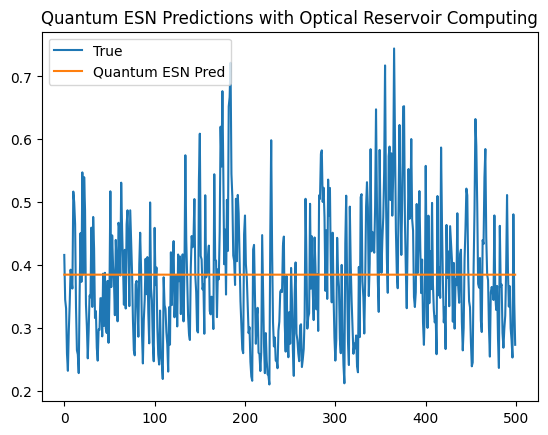

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")

# Plot Predictions
plt.plot(y_test, label="True")
plt.plot(predictions, label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

In [7]:
from reservoirs import CPRC, GBSampling

In [7]:
# res.CPMap().draw()

In [9]:
class CPEchoStateNetwork:
    def __init__(self, dim, regularization=1e-6):
        self.dim = dim
        self.quantum_reservoir = CPRC(dim = dim)
        self.regularization = regularization
        self.model = None  # Store the full Ridge model

    def fit(self, X, Y):
        quantum_states = np.array([self.quantum_reservoir.qc_func(x) for x in X])
        
        # Ensure shape consistency
        if quantum_states.ndim == 1:
            quantum_states = quantum_states.reshape(-1, 1)
        
        print("qst:", quantum_states)
        self.model = Ridge(alpha=self.regularization).fit(quantum_states, Y)

    def predict(self, X):
        if self.model is None:
            raise ValueErr
            or("Model has not been trained yet. Call `fit` first.")

        quantum_states = np.array([self.quantum_reservoir.qc_func(x) for x in X])
        
        # Ensure shape consistency
        if quantum_states.ndim == 1:
            quantum_states = quantum_states.reshape(-1, 1)
        
        print(quantum_states) 
        return self.model.predict(quantum_states)

In [10]:
models = {"QuantumESN": CPEchoStateNetwork(dim = 4)}
models["QuantumESN"].fit(X_train, y_train)

qst: [[0.04709584 0.19890992 0.14529865 ... 0.13979148 0.2932477  0.01920968]
 [0.06360367 0.18041088 0.16517488 ... 0.10002235 0.3038731  0.00953616]
 [0.06286174 0.20608046 0.14780642 ... 0.11429624 0.28609466 0.0105768 ]
 ...
 [0.03181499 0.22075149 0.13864793 ... 0.14226866 0.28184755 0.02974643]
 [0.04983409 0.19810516 0.15664696 ... 0.1172784  0.2977521  0.01630541]
 [0.05414434 0.19979751 0.15568415 ... 0.11453644 0.293938   0.01412444]]


In [11]:
predictions = models["QuantumESN"].predict(X_test)

[[0.05048835 0.20688722 0.15708405 ... 0.11346014 0.28921354 0.01581872]
 [0.03418994 0.20477307 0.1660403  ... 0.1088738  0.30248632 0.0257246 ]
 [0.04970078 0.20570091 0.14087614 ... 0.14017023 0.28668025 0.01788533]
 ...
 [0.03671486 0.21478256 0.13826978 ... 0.14623746 0.28309858 0.02609795]
 [0.04694491 0.1841596  0.17202448 ... 0.10274161 0.31327859 0.01654787]
 [0.07280479 0.20521549 0.12975499 ... 0.13252941 0.28188558 0.00874856]]


Quantum ESN RMSE: 0.0969


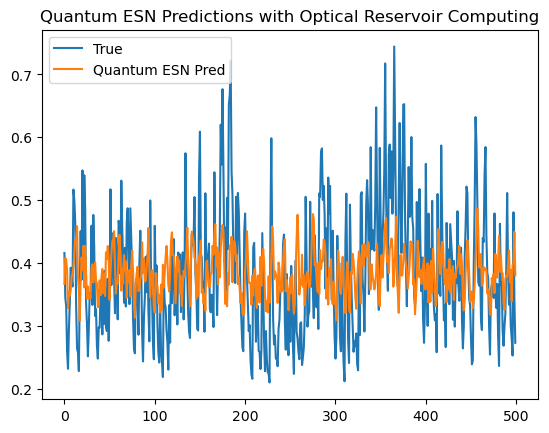

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")

# Plot Predictions
plt.plot(y_test, label="True")
plt.plot(predictions, label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

In [32]:
class GBEchoStateNetwork:
    def __init__(self, dim, regularization=1e-6, num_workers =4, parallel= False):
        self.dim = dim
        self.num_workers = num_workers
        self.parallel = parallel
        self.quantum_reservoir = GBSampling()
        self.regularization = regularization
        self.model = None  # Store the full Ridge model

    def fit(self, X, Y):
        quantum_states = np.array([self.quantum_reservoir.Probs(x, num_workers=self.num_workers, parallel = self.parallel) for x in X])
        
        # Ensure shape consistency
        if quantum_states.ndim == 1:
            quantum_states = quantum_states.reshape(-1, 1)
        
        self.model = Ridge(alpha=self.regularization).fit(quantum_states, Y)

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model has not been trained yet. Call `fit` first.")

        quantum_states = np.array([self.quantum_reservoir.Probs(x, num_workers=self.num_workers, parallel = self.parallel) for x in X])
        
        # Ensure shape consistency
        if quantum_states.ndim == 1:
            quantum_states = quantum_states.reshape(-1, 1)
        
        return self.model.predict(quantum_states)

    def predict_next_n_trained(self, initial_input, X_test, n, m):
        """
        Predicts the next n values while resetting to the true X_test values every m predictions.
    
        Parameters:
            initial_input (array-like): The initial input sequence to start predictions.
            X_test (array-like): The original test data to reset after every m predictions.
            n (int): Number of future values to predict.
            m (int): Reset interval (after how many predictions to reset to X_test).
    
        Returns:
            np.ndarray: Array of predicted values.
        """
        if self.model is None:
            raise ValueError("Model has not been trained yet. Call `fit` first.")
    
        predictions = []
        current_input = np.array(initial_input).reshape(1, -1) 
        test_index = 0  # Track X_test reset index
    
        for i in range(n):
            quantum_state = np.array([self.quantum_reservoir.Probs(current_input[0], 
                                                                  num_workers=self.num_workers, 
                                                                  parallel=self.parallel)])
    
            if quantum_state.ndim == 1:
                quantum_state = quantum_state.reshape(-1, 1)
    
            next_pred = self.model.predict(quantum_state)
            predictions.append(next_pred.flatten()[0])  # Store the scalar prediction
    
            # Every m predictions, reset to the true value from X_test
            if (i + 1) % m == 0 and test_index < len(X_test):
                current_input = np.array(X_test[test_index]).reshape(1, -1)  
                test_index += 1  
            else:
                current_input = np.roll(current_input, -1)  # Shift left
                current_input[0, -1] = next_pred.flatten()[0]  # Replace last element
    
        return np.array(predictions)


In [9]:
models = {"QuantumESN": GBEchoStateNetwork(dim = 4, num_workers=10, parallel =True)}
models["QuantumESN"].fit(X_train, y_train)

[np.float64(0.23162912346025338), np.float64(0.1960508965000492), np.float64(0.23722931801528363), np.float64(0.24249194236410476)]
[np.float64(0.23007368704684733), np.float64(0.2070081050146786), np.float64(0.2276667200583419), np.float64(0.24602290160246315)]
[np.float64(0.23348904161177597), np.float64(0.20374278633096754), np.float64(0.22978296900686926), np.float64(0.2459753399813747)]
[np.float64(0.22975100896717426), np.float64(0.20478118837770784), np.float64(0.22955221919308041), np.float64(0.24697798092940326)]
[np.float64(0.2359435233452656), np.float64(0.1948430158409087), np.float64(0.2405040721874505), np.float64(0.24120618224493415)]
[np.float64(0.2263970011945824), np.float64(0.198625357910368), np.float64(0.23878304033651004), np.float64(0.24414247996241703)]
[np.float64(0.23321692426552915), np.float64(0.1900921083382532), np.float64(0.24083990455535995), np.float64(0.241816731012045)]
[np.float64(0.2275584942318693), np.float64(0.20738310689854103), np.float64(0.226

In [10]:
predictions = models["QuantumESN"].predict(X_test)

[np.float64(0.23437826974443524), np.float64(0.20264410062350266), np.float64(0.23581980647919618), np.float64(0.24141874694495238)]
[np.float64(0.227576430791122), np.float64(0.2024569549001558), np.float64(0.23546691210976817), np.float64(0.24406370037824865)]
[np.float64(0.23311291230013395), np.float64(0.19634976303770868), np.float64(0.2363049247808336), np.float64(0.24356761561961332)]
[np.float64(0.22929952670707643), np.float64(0.20741913359665412), np.float64(0.22697464973591328), np.float64(0.24718893891342902)]
[np.float64(0.2349751811798731), np.float64(0.20038973883752625), np.float64(0.23355920021975093), np.float64(0.2445545117199171)]
[np.float64(0.22971543669172706), np.float64(0.20365483135086918), np.float64(0.2339488052041529), np.float64(0.2455660687771616)]
[np.float64(0.23163029155776102), np.float64(0.19245901180423527), np.float64(0.2383555139281597), np.float64(0.24465147741847817)]
[np.float64(0.23257402201455368), np.float64(0.1986850183480318), np.float64(0

Quantum ESN RMSE: 0.0822


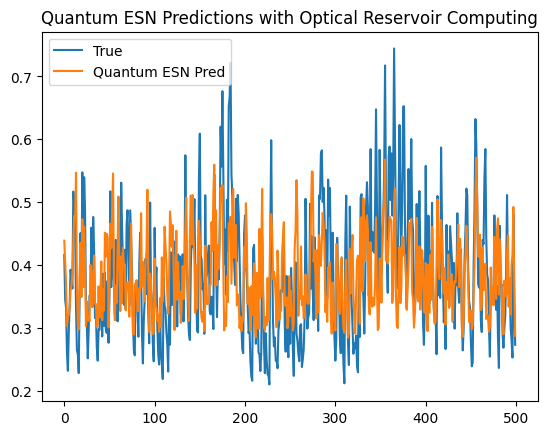

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")

# Plot Predictions
plt.plot(y_test, label="True")
plt.plot(predictions, label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

Quantum ESN RMSE: 0.0822


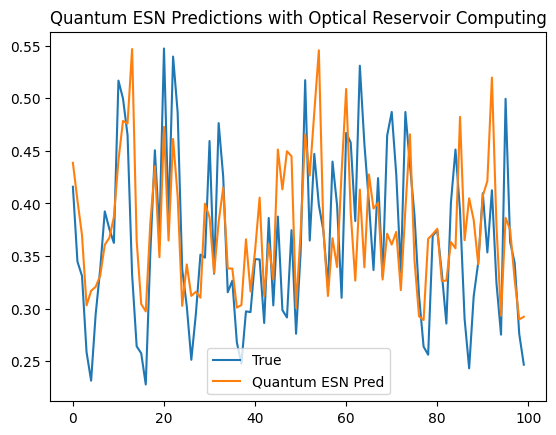

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")

# Plot Predictions
plt.plot(y_test[0:100], label="True")
plt.plot(predictions[0:100], label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

In [14]:
import joblib
joblib.dump(models["QuantumESN"], "GBSReservoir.pkl")

['GBSReservoir.pkl']

In [15]:
model = joblib.load("GBSReservoir.pkl")

In [27]:
X_test[0:1]

array([0.30974517, 0.23174702, 0.18989289, 0.43166682])

In [23]:
model.predict(X_test[0:1])

[np.float64(0.23437826974443524), np.float64(0.20264410062350266), np.float64(0.23581980647919618), np.float64(0.24141874694495238)]


array([0.43862067])

In [37]:
initial_input = X_test[0:1]

In [70]:
def predict_next_n_trained(self, initial_input, X_test, n, m):
    """
    Predicts the next n values while resetting to the true X_test values every m predictions.

    Parameters:
        initial_input (array-like): The initial input sequence to start predictions.
        X_test (array-like): The original test data to reset after every m predictions.
        n (int): Number of future values to predict.
        m (int): Reset interval (after how many predictions to reset to X_test).

    Returns:
        np.ndarray: Array of predicted values.
    """
    if self.model is None:
        raise ValueError("Model has not been trained yet. Call `fit` first.")

    predictions = []
    current_input = np.array(initial_input).reshape(1, -1) 
    test_index = 0  # Track X_test reset index

    for i in range(n):
        quantum_state = np.array([self.quantum_reservoir.Probs(current_input[0], 
                                                              num_workers=self.num_workers, 
                                                              parallel=self.parallel)])

        if quantum_state.ndim == 1:
            quantum_state = quantum_state.reshape(-1, 1)

        next_pred = self.model.predict(quantum_state)
        predictions.append(next_pred.flatten()[0])  # Store the scalar prediction

        # Every m predictions, reset to the true value from X_test
        if (i + 1) % m == 0 and test_index < len(X_test):
            current_input = np.array(X_test[test_index]).reshape(1, -1)  
            test_index += 1  
        else:
            current_input = np.roll(current_input, -1)  # Shift left
            current_input[0, -1] = next_pred.flatten()[0]  # Replace last element

    return np.array(predictions)


In [71]:
setattr(model, "predict_next_n_trained", predict_next_n_trained.__get__(model))

In [76]:
next_predictions = model.predict_next_n_trained(initial_input, X_test, n=50, m =4)
print(next_predictions)

[np.float64(0.23437826974443524), np.float64(0.20264410062350266), np.float64(0.23581980647919618), np.float64(0.24141874694495238)]
[np.float64(0.22912873512731952), np.float64(0.20202799696327375), np.float64(0.23754220805332946), np.float64(0.2412789785920967)]
[np.float64(0.23092010879007221), np.float64(0.19672789637113852), np.float64(0.23904005520182908), np.float64(0.23943082313210726)]
[np.float64(0.2298817302629163), np.float64(0.2040396163551963), np.float64(0.233952546856373), np.float64(0.23776487704265914)]
[np.float64(0.23437826974443524), np.float64(0.20264410062350266), np.float64(0.23581980647919618), np.float64(0.24141874694495238)]
[np.float64(0.22912873512731952), np.float64(0.20202799696327375), np.float64(0.23754220805332946), np.float64(0.2412789785920967)]
[np.float64(0.23092010879007221), np.float64(0.19672789637113852), np.float64(0.23904005520182908), np.float64(0.23943082313210726)]
[np.float64(0.2298817302629163), np.float64(0.2040396163551963), np.float64

In [77]:
next_predictions, y_test[0:50]

(array([0.43862067, 0.49273534, 0.55577385, 0.66667288, 0.43862067,
        0.49273534, 0.55577385, 0.66667288, 0.40293935, 0.45103469,
        0.53364951, 0.59317966, 0.36977924, 0.43549969, 0.48142405,
        0.54565217, 0.30296068, 0.36082355, 0.40133091, 0.44514277,
        0.31685965, 0.36089707, 0.4033541 , 0.45973388, 0.32074433,
        0.3719794 , 0.41894666, 0.47421276, 0.33124847, 0.37787862,
        0.42711016, 0.4831131 , 0.36068791, 0.40908324, 0.46267121,
        0.53181341, 0.36726851, 0.41735727, 0.47833886, 0.54142339,
        0.38692991, 0.44330997, 0.50089463, 0.57463174, 0.44093629,
        0.49806324, 0.57121111, 0.66880553, 0.47841724, 0.54627611]),
 array([0.41589211, 0.34464753, 0.3309876 , 0.25851707, 0.23143596,
        0.29460784, 0.33765416, 0.39240959, 0.37579608, 0.36242635,
        0.5167759 , 0.49969966, 0.46503145, 0.33241041, 0.26412322,
        0.25744202, 0.2278046 , 0.35253478, 0.45056896, 0.37299593,
        0.54734292, 0.38491292, 0.5396691 , 0.

Quantum ESN RMSE: 0.1686


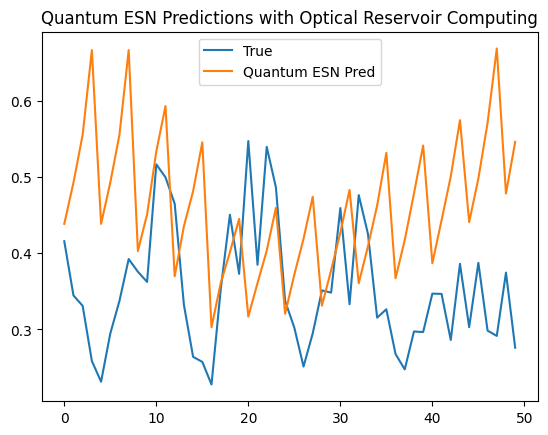

In [78]:
rmse = np.sqrt(mean_squared_error(y_test[0:50], next_predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")

# Plot Predictions
plt.plot(y_test[0:50], label="True")
plt.plot(next_predictions, label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

In [23]:
from reservoirs import CPRC, GBSampling
gbs = GBSampling(cutoff = 40, value = 2, avgPhotons=3)
a = np.array([0.1,0.2,0.65,0.98])

In [24]:
%%time
gbs.Probs(a, num_workers=4, parallel=False)

CPU times: user 2.91 s, sys: 187 ms, total: 3.1 s
Wall time: 3.1 s


[np.float64(0.13726413552823838),
 np.float64(0.11614384443681856),
 np.float64(0.14568299819959893),
 np.float64(0.1426765667830613)]

In [20]:
%%time
gbs.Probs(a, num_workers=4, parallel=False)

CPU times: user 2.9 s, sys: 196 ms, total: 3.09 s
Wall time: 3.08 s


[np.float64(0.22719110674855314),
 np.float64(0.19725521144904026),
 np.float64(0.2423625274219918),
 np.float64(0.23146719753773212)]